In [1]:
!pip install annoy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=551810 sha256=46ca7aa02509f63bcb08bbc6503ea36b10a0424ba9ff25b389f1ebecded34f33
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


In [2]:
from annoy import AnnoyIndex
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
df = pd.read_csv("/content/gdrive/MyDrive/ml/restnet50/vectorCSV/trainVectors.csv")
filenames = df["filename"].values
vectors = df.drop(columns=["filename"]).values

In [19]:
CNN = joblib.load("/content/gdrive/MyDrive/ml/restnet50/CNN.sav")
restnet = joblib.load('/content/gdrive/MyDrive/ml/restnet50/restnet50.sav')
scaler = joblib.load('/content/gdrive/MyDrive/ml/restnet50/scaler/stdScaler.pkl')
pca = joblib.load('/content/gdrive/MyDrive/ml/restnet50/scaler/pca.pkl')

In [13]:
vector_dim = vectors.shape[1]
ann_index = AnnoyIndex(vector_dim, metric='euclidean')

for i, v in enumerate(vectors):
    ann_index.add_item(i, v.tolist())

ann_index.build(1000)
ann_index.save("image_features.ann")

True

In [15]:
minMaxscaler = joblib.load('/content/gdrive/MyDrive/ml/restnet50/scaler/minMaxScaler.pkl')

In [23]:
def extract_feature(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    features = restnet.predict(x, verbose=0)
    print(features.shape)
    features = features.reshape((1, -1))
    features = pca.transform(features)
    print(features.shape)
    features = scaler.transform(features)
    features = features.reshape(-1)
    features = CNN.predict(features.reshape(1, -1))
    features = minMaxscaler.transform(features)


    return features.flatten()

In [17]:
def find_similar_images(img_path, top_k=10):
    query_vec = extract_feature(img_path)
    idxs = ann_index.get_nns_by_vector(query_vec, top_k, include_distances=True)
    results = [(filenames[i], d) for i, d in zip(idxs[0], idxs[1])]
    return results

In [24]:
queryImg = "180.jpg"
similar = find_similar_images(queryImg)

for fname, dist in similar:
    print(f"{fname}  (distance={dist:.4f})")

(1, 2048)
(1, 512)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Stonehenge/78.Stonehenge.jpg  (distance=3807.0801)
Chich-n Itz - Mexico/12.kukulkan-pyramid-archeological-site-chichen-260nw-480948610.jpg  (distance=3809.2466)
Stonehenge/111.jpg  (distance=3810.9678)
Great Wall Of China - China/39.jpg  (distance=3812.9570)
Great Wall Of China - China/46.jpg  (distance=3813.9707)
Himalaya - India/29.himalayas-India-Luxury-Travel-Ker-Downey.jpg  (distance=3814.2991)
Christ the Reedemer Statue/13.00446-mn-11acvx2sjy1279.jpg  (distance=3816.4963)
Antarctica/111.jpg  (distance=3816.5447)
Eiffel Tower - Paris/80.eiffel-tower-at-night.jpg  (distance=3817.7527)
Eiffel Tower - Paris/18.eiffel-tower-paris-france-16.jpg  (distance=3819.7927)


In [ ]:
similar

(1, 2048)
(1, 512)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


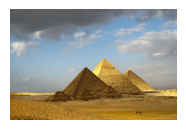

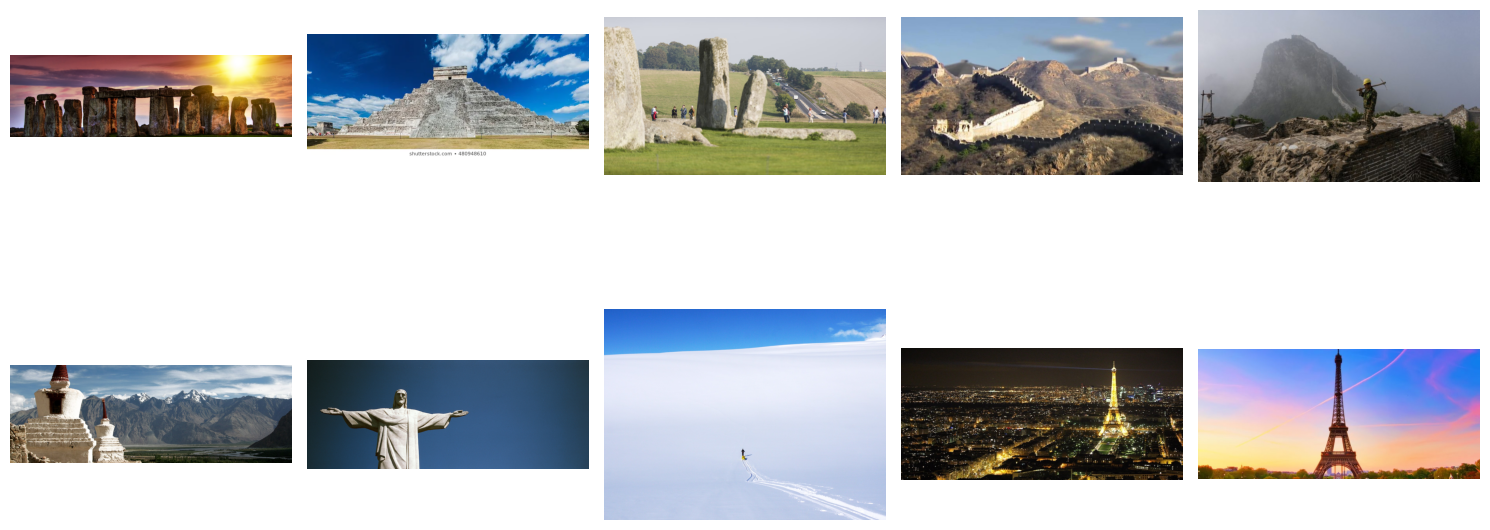

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

similar = find_similar_images(queryImg)
pathh = '/content/gdrive/MyDrive/train'

plt.figure(figsize=(15, 8))
plt.subplot(2, 6, 1)
img = mpimg.imread(queryImg)
plt.imshow(img)
plt.axis('off')
plt.show()

plt.figure(figsize=(15, 8))
for i, (fname, dist) in enumerate(similar[:10], start=1):
    plt.subplot(2, 5, i)
    similar_image_full_path = os.path.join(pathh, fname)
    img = mpimg.imread(similar_image_full_path)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()